In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches
import torch_geometric
from torch.utils.data import Dataset, DataLoader


In [16]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.01, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx = 500
dt0 = 1e-4
nu = 0.01
n_steps = 20000   # match MLP experiment

x, data = generate_diffusion_data(Nx, nu, dt0, n_steps)



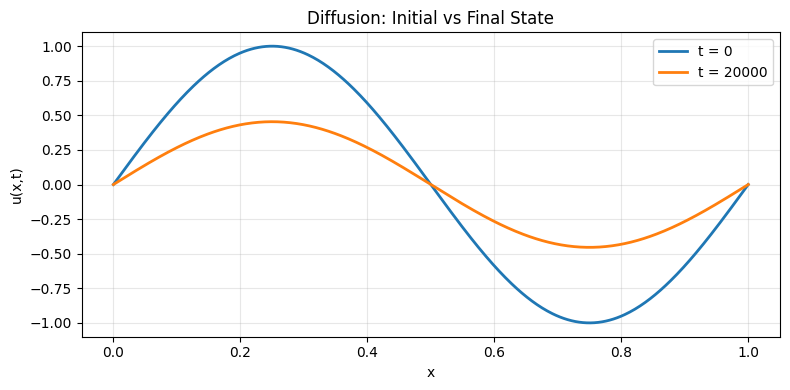

In [17]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
def sample_one_B(u, R=10, k=5, max_tries=50, u_scale=None):
    """
    Sample a single Scheme-B training example.
    
    - Pick a random center (t0, x0).
    - Build an ellipse of radius R in t, and R * Nx/Nt in x.
    - Randomly pick k points inside the ellipse as neighbors.
    - Return:
        feats_flat: shape (k * 3,) with [dt_scaled, dx_scaled, u_scaled] per neighbor
        target: scalar, normalized u at (t0, x0)
    """
    Nt, Nx = u.shape
    
    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8
    
    for _ in range(max_tries):
        # 1) random center
        t0 = np.random.randint(0, Nt)
        x0 = np.random.randint(0, Nx)
        
        # 2) ellipse radii in index coordinates
        Rt = R
        Rx = R  
        
        # bounding box for ellipse
        t_min = max(0, int(t0 - Rt))
        t_max = min(Nt - 1, int(t0 + Rt))
        x_min = max(0, int(x0 - Rx))
        x_max = min(Nx - 1, int(x0 + Rx))
        
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if (t == t0 and x == x0):
                    continue
                dt_ell = (t - t0) / Rt
                dx_ell = (x - x0) / Rx
                if dt_ell*dt_ell + dx_ell*dx_ell <= 1.0:
                    cand.append((t, x))
        
        if len(cand) < k:
            # too few neighbors, try another center
            continue
        
        # 3) choose k random neighbors from candidates
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]   # shape (k, 2)
        
        # 4) build features
        feats = []
        for (tn, xn) in neigh:
            # relative indices scaled by ellipse radii
            dt_scaled = (t0 - tn) / Rt
            dx_scaled = (x0 - xn) / Rx
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])
        
        feats = np.array(feats, dtype=np.float32).reshape(-1)  # (k*3,)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target
    
    raise RuntimeError("Failed to sample B-example; try changing R/k.")


In [19]:
class GNNIntegrator(nn.Module):
    def __init__(self, k=5, hidden=512, num_layers=3, dropout=0.0):
        super().__init__()
        self.k = k
        self.hidden = hidden
        self.num_layers = num_layers

        self.edge_mlp = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
        )

        msg_layers = []
        for _ in range(num_layers):
            msg_layers.append(nn.Linear(hidden, hidden))
            msg_layers.append(nn.ReLU())
        self.msg_mlp = nn.Sequential(*msg_layers)

        self.output = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        B = x.shape[0]
        x = x.view(B, self.k, 3)

        edge = x[:, :, :2].reshape(B * self.k, 2)
        node = x[:, :, 2:3].reshape(B * self.k, 1)

        e = self.edge_mlp(edge).view(B, self.k, self.hidden)
        n = self.node_mlp(node).view(B, self.k, self.hidden)

        msg = (e + n).sum(dim=1)      # (B, hidden)
        msg = self.msg_mlp(msg)
        return self.output(msg).squeeze(-1)


In [20]:
def train_integrator_B_gnn(
    u, epochs=50, batch_size=4096, k=5, R=5,
    N_samples=100000, lr=1e-3, hidden=512, num_layers=3,
    device="cpu", use_amp=True, pregenerate=True
):
    """
    Train GNN integrator with same experimental setup as MLP pipeline.
    """

    device = torch.device(device)
    
    print("Setting up dataset...")
    dataset = BDataset(u, N_samples=N_samples, R=R, k=k, pregenerate=pregenerate)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0 if pregenerate else 4,
        pin_memory=True
    )

    model = GNNIntegrator(k=k, hidden=hidden, num_layers=num_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    loss_fn = nn.MSELoss()

    if use_amp and device.type == "cpu":
        scaler = torch.cpu.amp.GradScaler()
    else:
        scaler = None

    print(f"Training on device: {device}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Samples: {N_samples:,}, batch={batch_size}")
    print(f"Mixed precision: {use_amp}")

    # Warmup batch
    if device.type == 'cpu':
        model.train()
        warm_feats, warm_target = next(iter(loader))
        warm_feats = warm_feats.to(device)
        warm_target = warm_target.to(device)
        print("\nGPU warmup...")
        for _ in range(3):
            opt.zero_grad()
            with torch.cpu.amp.autocast(enabled=use_amp):
                pred = model(warm_feats)
                loss = loss_fn(pred, warm_target)
            loss.backward()
            opt.step()
        torch.cpu.synchronize()
        print("Warmup complete.\n")

    import time
    total_batches = len(loader)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        start = time.time()

        for feats, target in loader:
            feats = feats.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            opt.zero_grad()

            if scaler:
                with torch.cpu.amp.autocast():
                    pred = model(feats)
                    loss = loss_fn(pred, target)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
            else:
                pred = model(feats)
                loss = loss_fn(pred, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            total_loss += loss.item() * feats.size(0)

        avg_loss = total_loss / len(dataset)
        scheduler.step(avg_loss)
        lr_now = opt.param_groups[0]['lr']
        dur = time.time() - start

        print(f"[Epoch {epoch+1}/{epochs}] loss={avg_loss:.6e}, lr={lr_now:.2e}, time={dur:.1f}s")

    return model.to(device), dataset


In [21]:
def eval_integrator_B_gnn(
    model,
    dataset,
    N_test=10000,
    batch_size=4096,
    device="cpu",
    use_amp=True
):
    device = torch.device(device)
    model.eval()

    # fresh test dataset with different seed, pre-generate for speed
    test_ds = BDataset(
        dataset.u,
        N_samples=N_test,
        R=dataset.R,
        k=dataset.k,
        seed=123,
        pregenerate=True
    )

    loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    loss_fn = nn.MSELoss()
    total_loss = 0.0

    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            if use_amp and device.type == 'cpu':
                with torch.amp.autocast(device_type='cpu'):
                    pred = model(feats)
                    loss = loss_fn(pred, target)
            else:
                pred = model(feats)
                loss = loss_fn(pred, target)

            total_loss += loss.item() * feats.size(0)

    avg_loss = total_loss / N_test
    print(f"[Eval GNN B] MSE = {avg_loss:.6e}")
    return avg_loss


In [22]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution on fine grid, shape (Nt, Nx)
    - N_samples: number of samples to generate on the fly or pre-generate
    """
    def __init__(self, u, N_samples=50000, R=5, k=5, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)
        
        # global u-scale for normalization
        self.u_scale = np.max(np.abs(u)) + 1e-8
        
        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples for BDataset...")
            feats_list = []
            targets_list = []
            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples}")
                np.random.set_state(self.rng.get_state())
                feats, target = sample_one_B(
                    self.u,
                    R=self.R,
                    k=self.k,
                    u_scale=self.u_scale
                )
                self.rng.random_sample()
                feats_list.append(feats)
                targets_list.append(target)
            
            self.feats_tensor = torch.from_numpy(
                np.array(feats_list, dtype=np.float32)
            )
            self.targets_tensor = torch.from_numpy(
                np.array(targets_list, dtype=np.float32)
            )
            print("Pre-generation complete.")

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        if self.pregenerate:
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            np.random.set_state(self.rng.get_state())
            feats, target = sample_one_B(
                self.u,
                R=self.R,
                k=self.k,
                u_scale=self.u_scale
            )
            self.rng.random_sample()
            return torch.from_numpy(feats), torch.tensor(target, dtype=torch.float32)


In [23]:
model, train_ds = train_integrator_B_gnn(
    data,
    epochs=150,
    batch_size=4096,
    k=5,
    R=5,
    N_samples=100000,
    lr=1e-3,
    hidden=512,
    num_layers=3,
    device="cpu",
    use_amp=True,
    pregenerate=True
)


Setting up dataset...
Pre-generating 100000 samples for BDataset...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000


KeyboardInterrupt: 

In [ ]:
model_save_path = "model_integrator_gnn.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'model_type': 'gnn',
    'arch_version': 1,
    'k': 5,
    'R': train_ds.R,
    'hidden': model.hidden,
    'num_layers': model.num_layers if hasattr(model, 'num_layers') else None,
    'u_scale': train_ds.u_scale,
    'Nx': data.shape[1],
    'Nt': data.shape[0],
}, model_save_path)

print(f"GNN model saved to {model_save_path}")


NameError: name 'model' is not defined

In [35]:
def visualize_B_with_prediction_gnn(u, model, R=5, k=5, device="cpu"):
    model.eval()
    device = torch.device(device)
    
    Nt, Nx = u.shape

    # --- sample target center (t0, x0) ---
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # --- collect circle neighbors (match Scheme-B) ---
    Rt = Rx = R
    t_min = max(0, t0 - Rt)
    t_max = min(Nt - 1, t0 + Rt)
    x_min = max(0, x0 - Rx)
    x_max = min(Nx - 1, x0 + Rx)

    cand = []
    for t in range(t_min, t_max + 1):
        dt = t - t0
        dt2 = dt * dt
        if dt2 > R * R:
            continue
        for x in range(x_min, x_max + 1):
            if (t == t0 and x == x0):
                continue
            dx = x - x0
            if dt2 + dx * dx <= R * R:
                cand.append((t, x))

    cand = np.array(cand)
    assert len(cand) >= k, "Not enough neighbors sampled!"

    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]

    # --- build features for network ---
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        dt_scaled = (t0 - tn) / R
        dx_scaled = (x0 - xn) / R
        u_scaled = u[tn, xn] / u_scale
        feats.append([dt_scaled, dx_scaled, u_scaled])

    feats = np.array(feats, dtype=np.float32).reshape(1, -1)
    feats_t = torch.from_numpy(feats).to(device, non_blocking=True)

    # --- prediction ---
    with torch.no_grad():
        use_amp = (device.type == 'cpu')
        if use_amp:
            try:
                with torch.amp.autocast(device_type='cpu'):
                    pred = model(feats_t).item() * u_scale
            except AttributeError:
                # fallback for older PyTorch
                with torch.cpu.amp.autocast():
                    pred = model(feats_t).item() * u_scale
        else:
            pred = model(feats_t).item() * u_scale

    true = u[t0, x0]
    err  = pred - true
    pct  = abs(err)/true  * 100.0   # percent error

    fig, ax = plt.subplots(figsize=(5, 5))

    # circle
    circle = patches.Circle((x0, t0), radius=R, fill=False,
                            edgecolor='blue', linewidth=1.5)
    ax.add_patch(circle)

    # neighbors (NO label)
    ax.scatter(neigh[:, 1], neigh[:, 0], s=120, c='blue')
    for (tn, xn) in neigh:
        ax.plot([x0, xn], [t0, tn], color='cyan', alpha=0.6)

    # target (NO label)
    ax.scatter([x0], [t0], c='red', s=200)

    # legend text only
    text = (f"true = {true:.5f}\n"
            f"pred = {pred:.5f}\n"
            f"err  = {err:.5f}\n"
            f"%err = {pct:.2f}%")

    dummy = plt.Line2D([], [], linestyle='none', marker='', label=text)
    ax.legend(handles=[dummy], loc='upper right', fontsize=9, framealpha=0.95)

    pad = 2
    ax.set_xlim(x0 - R - pad, x0 + R + pad)
    ax.set_ylim(t0 + R + pad, t0 - R - pad)
    ax.set_aspect('equal')
    ax.set_xlabel("x (space index)")
    ax.set_ylabel("t (time index, upward)")
    ax.set_title("GNN prediction on Scheme-B neighborhood")
    plt.tight_layout()
    plt.show()


In [36]:
def load_integrator_model_gnn(model_path, device="cpu"):
    """
    Load a saved GNN integrator model and associated config.
    """
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    model_type = checkpoint.get('model_type', 'gnn')
    assert model_type == 'gnn', f"Expected gnn model, got {model_type}"

    k = checkpoint['k']
    R = checkpoint['R']
    hidden = checkpoint['hidden']
    num_layers = checkpoint.get('num_layers', 3)
    u_scale = checkpoint['u_scale']
    Nx = checkpoint['Nx']
    Nt = checkpoint['Nt']

    model = GNNIntegrator(
        k=k,
        hidden=hidden,
        num_layers=num_layers
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = {
        'model_type': model_type,
        'k': k,
        'R': R,
        'hidden': hidden,
        'num_layers': num_layers,
        'u_scale': u_scale,
        'Nx': Nx,
        'Nt': Nt,
    }

    print(f"[load] GNN loaded from {model_path}")
    print(f"Config: k={k}, R={R}, hidden={hidden}, num_layers={num_layers}, u_scale={u_scale:.3e}")

    return model, config


In [37]:
model, cfg = load_integrator_model_gnn("model_integrator_gnn.pth", device="cpu")


[load] GNN loaded from model_integrator_gnn.pth
Config: k=5, R=5, hidden=512, num_layers=3, u_scale=1.000e+00


In [ ]:
# Visualize a prediction
 
eval_integrator_B_gnn(model, train_ds)



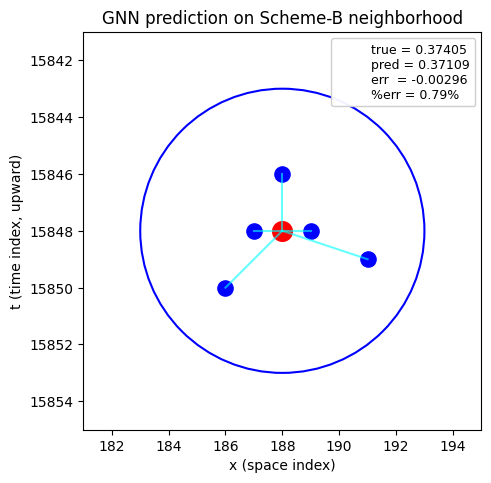

In [64]:
visualize_B_with_prediction_gnn(data, model)